# 전기차 에너지 소비율 예측 프로젝트 - EDA·모델 개선·후보 경로 비교

## 분석 목적
주행 조건과 전기차 에너지 소비율(`energy_consumption_kwhper100km`)의 관계를 확인한 뒤, 여러 회귀모델의 예측 성능을 비교하여 내비게이션 적용에 적합한 모델을 찾습니다.

> `kWh/100km`는 100km를 주행할 때 소비하는 에너지이므로 값이 클수록 에너지 소비가 많습니다.

## 1. 라이브러리 불러오기
회귀 실습자료에서 사용한 `pandas`, `numpy`, `matplotlib`만 사용합니다.

In [76]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.unicode_minus'] = False

In [77]:
# 한글 깨짐 해결
import matplotlib.pyplot as plt
import matplotlib as mpl

# 한글 폰트 설정
import platform

from matplotlib import rc
plt.rcParams['axes.unicode_minus'] = False

if platform.system() == 'Linux':
    rc('font', family = 'NanumGothic')  # 또는 '나눔고딕'
    print('Linux system... font set to NanumGothic')
elif platform.system() == 'Windows':
    rc('font', family = 'Malgun Gothic')   # 또는 '맑은 고딕'
    print('Windows system... font set to Malgun Gothic')
else:
    print('Unknown system... sorry~~~~')

plt.rc('axes', unicode_minus=False)     # 마이너스 깨짐 방지

Linux system... font set to NanumGothic


## 2. 데이터 불러오기
프로젝트 폴더를 기준으로 `datas_ml/ev_energy_consumption.csv`를 불러옵니다.

In [78]:
csv_path = 'datas_ml/ev_energy_consumption.csv'

if not os.path.exists(csv_path):
    raise FileNotFoundError(f'CSV 파일을 찾을 수 없습니다: {csv_path}')

df = pd.read_csv(csv_path)
print('데이터 크기:', df.shape)
df.head()

데이터 크기: (8000, 10)


,speed_kmh,payload_kg,ambient_temp_C,hvac_power_kw,road_grade_pct,battery_temp_C,driving_style_index,tire_pressure_bar,trip_distance_km,energy_consumption_kwhper100km
0,61.2,360.1,-9.8,3.43,-4.65,24.0,0.687,2.38,35.7,25.357
1,124.6,343.6,-10.0,2.34,-4.90,17.8,0.413,2.79,9.1,25.554
2,100.5,47.9,13.6,0.28,-2.08,18.8,0.280,2.58,68.8,18.004
3,85.9,461.3,-8.5,4.59,5.39,20.4,0.616,2.68,165.7,34.539
4,37.2,284.2,38.7,4.90,6.76,21.1,0.740,2.35,8.0,26.883


## 3. 데이터 구조와 품질 확인
행·열의 개수, 자료형, 결측치, 중복값을 확인합니다.

In [79]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 10 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   speed_kmh                       8000 non-null   float64
 1   payload_kg                      8000 non-null   float64
 2   ambient_temp_C                  8000 non-null   float64
 3   hvac_power_kw                   8000 non-null   float64
 4   road_grade_pct                  8000 non-null   float64
 5   battery_temp_C                  8000 non-null   float64
 6   driving_style_index             8000 non-null   float64
 7   tire_pressure_bar               8000 non-null   float64
 8   trip_distance_km                8000 non-null   float64
 9   energy_consumption_kwhper100km  8000 non-null   float64
dtypes: float64(10)
memory usage: 625.1 KB


In [80]:
quality_check = pd.DataFrame({
    '결측치 수': df.isnull().sum(),
    '고유값 수': df.nunique(),
    '자료형': df.dtypes.astype(str)
})

print('중복 행 수:', df.duplicated().sum())
quality_check

중복 행 수: 0


,결측치 수,고유값 수,자료형
speed_kmh,0,1101,float64
payload_kg,0,4021,float64
ambient_temp_C,0,501,float64
hvac_power_kw,0,501,float64
road_grade_pct,0,1297,float64
battery_temp_C,0,301,float64
driving_style_index,0,1001,float64
tire_pressure_bar,0,81,float64
trip_distance_km,0,1911,float64
energy_consumption_kwhper100km,0,6056,float64


In [81]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
speed_kmh,8000.0,74.427013,31.789245,20.00,46.775,74.2000,101.800,130.0
payload_kg,8000.0,248.822563,144.327869,0.00,124.300,246.8500,376.125,500.0
ambient_temp_C,8000.0,15.587013,14.396150,-10.00,3.475,15.8000,27.900,40.0
hvac_power_kw,8000.0,2.477026,1.435208,0.00,1.230,2.4800,3.700,5.0
road_grade_pct,8000.0,1.464087,3.744704,-5.00,-1.790,1.5000,4.670,8.0
battery_temp_C,8000.0,29.970725,8.717058,15.00,22.300,29.9000,37.700,45.0
driving_style_index,8000.0,0.499641,0.286885,0.00,0.254,0.5020,0.745,1.0
tire_pressure_bar,8000.0,2.401016,0.230790,2.00,2.200,2.4000,2.600,2.8
trip_distance_km,8000.0,102.692337,55.844911,5.10,54.300,103.2500,151.700,200.0
energy_consumption_kwhper100km,8000.0,24.137613,3.738082,11.62,21.514,24.0925,26.753,35.0


### 데이터 품질 1차 해석
- 데이터는 **8,000행 × 10열**로 구성되어 있습니다.
- 입력변수는 9개이고 목표변수는 1개입니다.
- 결측치와 중복 행은 없습니다.
- 모든 변수가 수치형이므로 범주형 인코딩은 필요하지 않습니다.
- 값이 물리적으로 가능한 범위인지와 극단값의 영향은 그래프로 추가 확인합니다.

## 4. 목표변수 분포 확인
목표변수는 `energy_consumption_kwhper100km`입니다. 분포가 지나치게 한쪽으로 치우쳤는지 확인합니다.

count    8000.000000
mean       24.137613
std         3.738082
min        11.620000
25%        21.514000
50%        24.092500
75%        26.753000
max        35.000000
Name: energy_consumption_kwhper100km, dtype: float64
왜도: 0.033


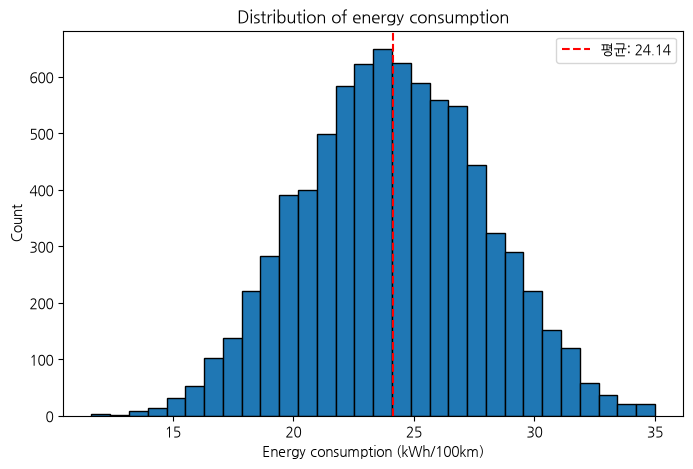

In [82]:
target = 'energy_consumption_kwhper100km'

print(df[target].describe())
print(f'왜도: {df[target].skew():.3f}')

plt.figure(figsize=(8, 5))
plt.hist(df[target], bins=30, edgecolor='black')
plt.axvline(df[target].mean(), color='red', linestyle='--', label=f'평균: {df[target].mean():.2f}')
plt.xlabel('Energy consumption (kWh/100km)')
plt.ylabel('Count')
plt.title('Distribution of energy consumption')
plt.legend()
plt.show()

### 목표변수 1차 해석
에너지 소비율은 약 **11.62~35.00 kWh/100km** 범위이며 왜도가 0에 가까워 좌우 치우침이 크지 않습니다. 따라서 목표변수에 로그 변환을 적용할 필요성은 낮아 보입니다.

## 5. 목표변수와 각 변수의 선형 상관관계
상관계수의 절댓값이 클수록 두 변수의 **직선 관계**가 강합니다. 상관관계는 인과관계를 의미하지 않으며, 곡선 관계는 낮게 나타날 수 있습니다.

In [83]:
correlation = (
    df.corr(numeric_only=True)[target]
      .drop(target)
      .sort_values(key=abs, ascending=False)
)

correlation.to_frame('목표변수와의 상관계수')

,목표변수와의 상관계수
road_grade_pct,0.504623
payload_kg,0.468906
speed_kmh,0.448316
hvac_power_kw,0.369619
driving_style_index,0.258434
trip_distance_km,0.171982
ambient_temp_C,-0.155499
tire_pressure_bar,-0.095066
battery_temp_C,-0.086873


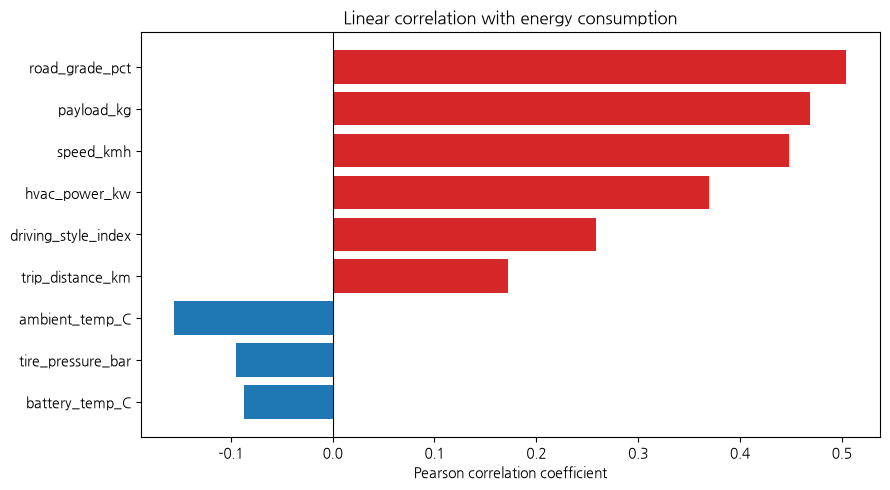

In [84]:
colors = ['tab:red' if value > 0 else 'tab:blue' for value in correlation]

plt.figure(figsize=(9, 5))
plt.barh(correlation.index[::-1], correlation.values[::-1], color=colors[::-1])
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Pearson correlation coefficient')
plt.title('Linear correlation with energy consumption')
plt.tight_layout()
plt.show()

### 상관관계 1차 해석
- 양의 상관관계가 큰 변수: **도로 경사도 → 적재중량 → 속도 → 공조 전력** 순입니다.
- 운전 습관 지수와 주행거리도 약한 양의 관계를 보입니다.
- 외기온, 타이어 공기압, 배터리 온도는 약한 음의 상관관계로 나타납니다.
- 이는 각 변수를 하나씩 비교한 결과입니다. 다른 조건을 함께 통제한 영향은 회귀모델에서 다시 확인해야 합니다.

## 6. 변수별 산점도 확인
산점도를 이용해 관계의 방향, 퍼짐 정도, 이상치와 비선형 패턴을 확인합니다.

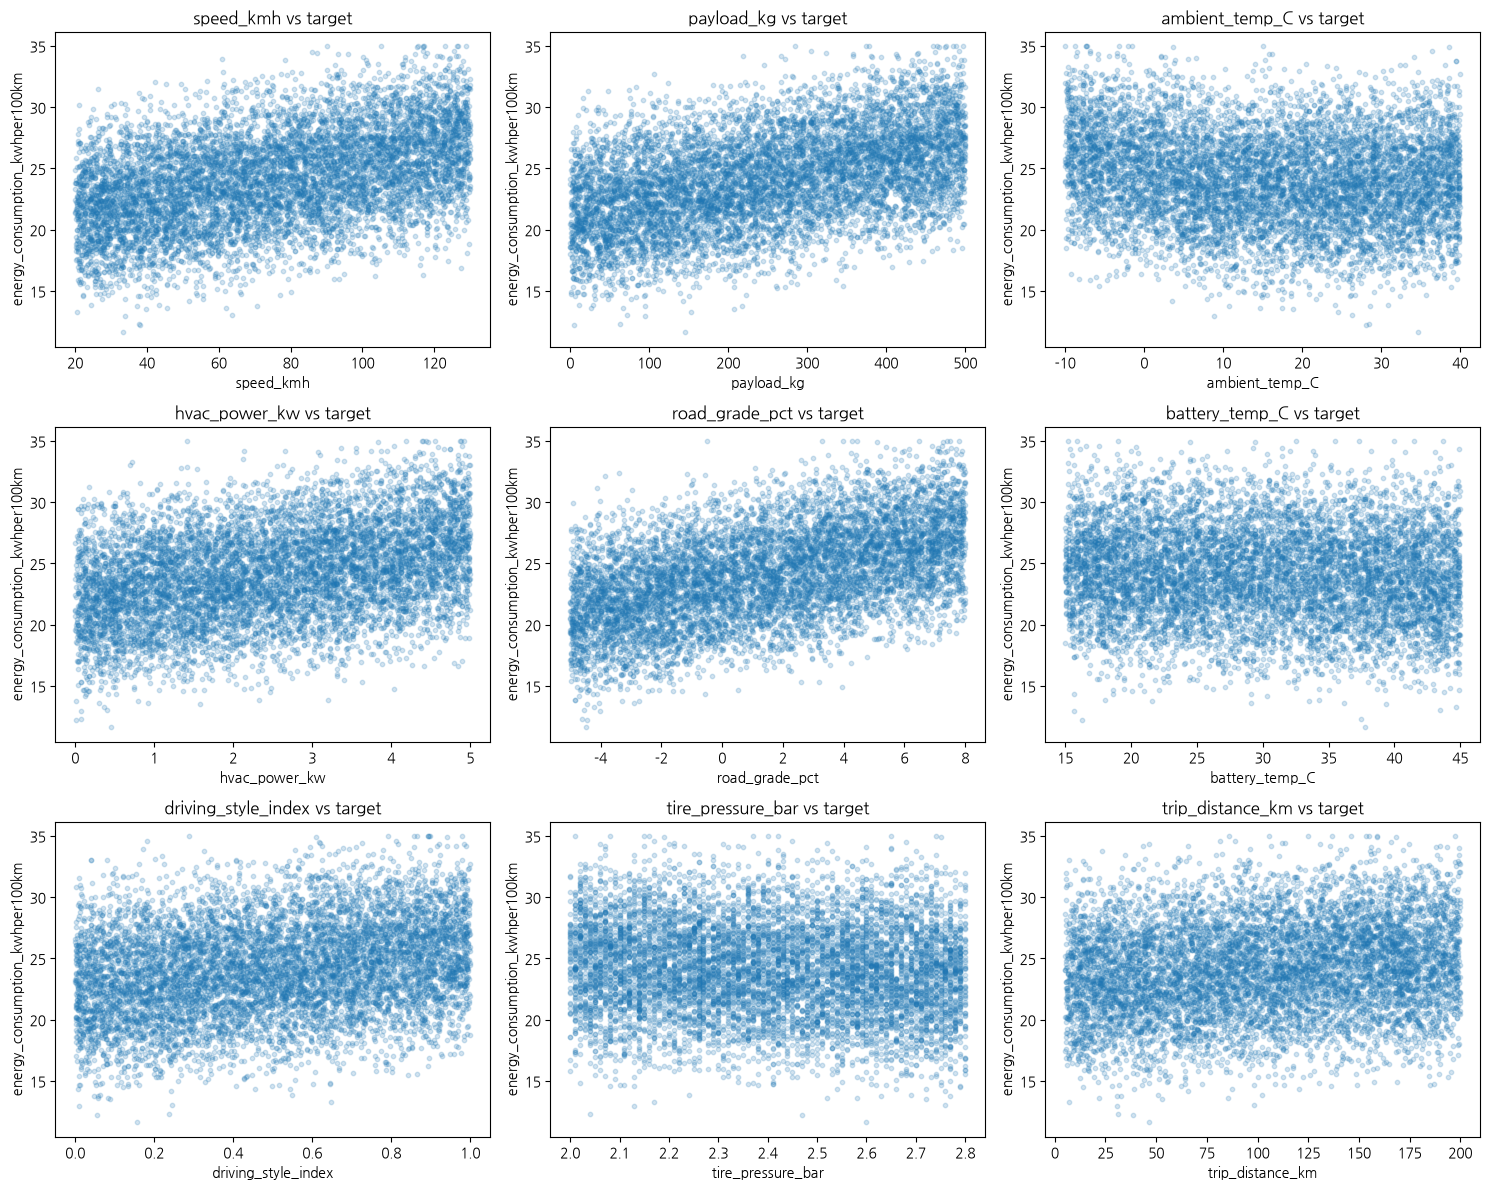

In [85]:
features = [column for column in df.columns if column != target]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for ax, feature in zip(axes, features):
    ax.scatter(df[feature], df[target], alpha=0.20, s=10)
    ax.set_xlabel(feature)
    ax.set_ylabel(target)
    ax.set_title(f'{feature} vs target')

plt.tight_layout()
plt.show()

## 7. 구간별 평균으로 비선형 관계 확인
각 입력변수를 비슷한 개수의 10개 구간으로 나누고 구간별 평균 에너지 소비율을 계산합니다. 산점도에서 흐릿했던 곡선 관계를 확인하는 보조 분석입니다.

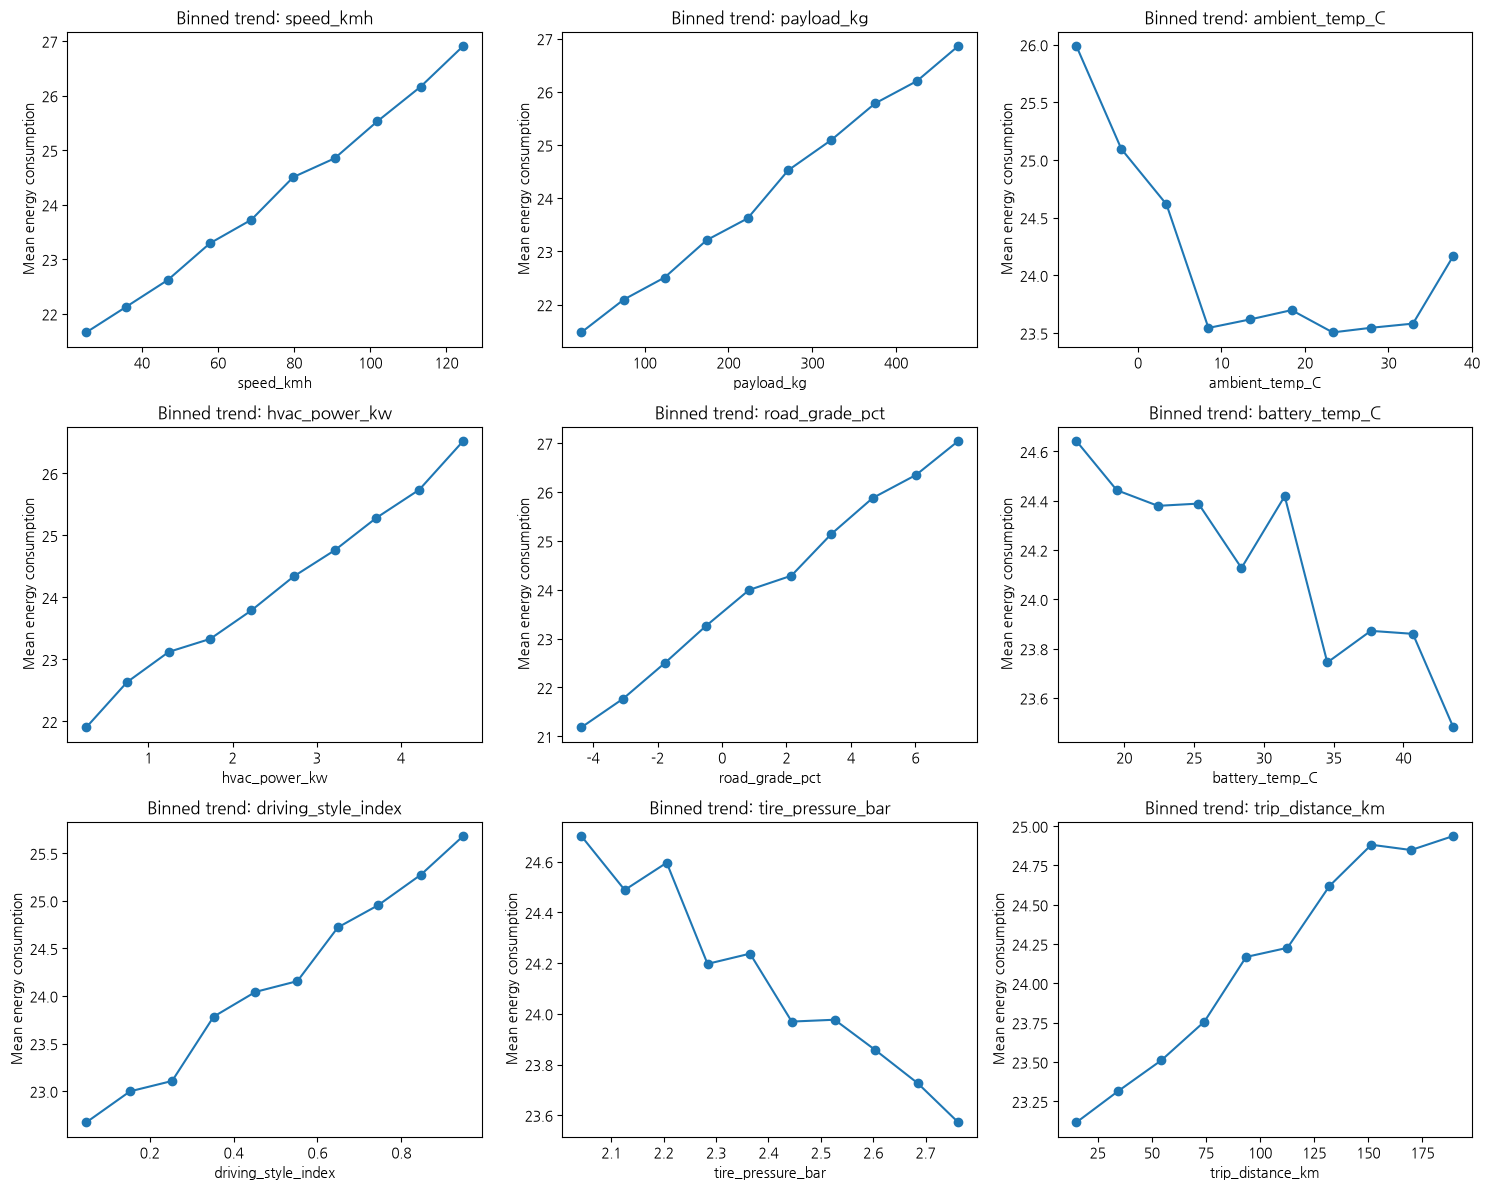

In [86]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for ax, feature in zip(axes, features):
    temp = df[[feature, target]].copy()
    temp['group'] = pd.qcut(temp[feature], q=10, duplicates='drop')
    grouped = temp.groupby('group', observed=False).agg(
        feature_mean=(feature, 'mean'),
        target_mean=(target, 'mean')
    )
    ax.plot(grouped['feature_mean'], grouped['target_mean'], marker='o')
    ax.set_xlabel(feature)
    ax.set_ylabel('Mean energy consumption')
    ax.set_title(f'Binned trend: {feature}')

plt.tight_layout()
plt.show()

## 8. 입력변수끼리의 상관관계 확인
입력변수끼리 지나치게 높은 상관관계가 있으면 선형회귀 계수의 해석이 불안정해질 수 있습니다.

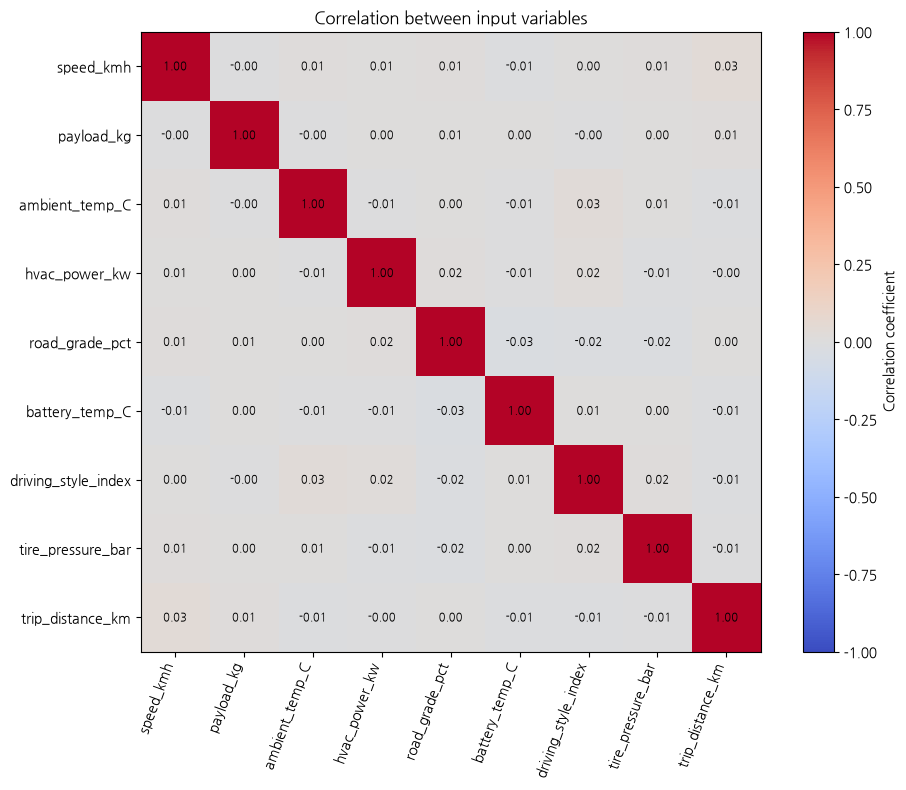

In [87]:
feature_corr = df[features].corr()

fig, ax = plt.subplots(figsize=(10, 8))
image = ax.imshow(feature_corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(features)))
ax.set_yticks(range(len(features)))
ax.set_xticklabels(features, rotation=70, ha='right')
ax.set_yticklabels(features)

for i in range(len(features)):
    for j in range(len(features)):
        ax.text(j, i, f'{feature_corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8)

fig.colorbar(image, ax=ax, label='Correlation coefficient')
ax.set_title('Correlation between input variables')
plt.tight_layout()
plt.show()

## 9. 회귀모델 학습 준비

EDA에서 상관계수가 낮았던 변수도 다른 변수와 함께 사용하거나 비선형 모델에서 예측에 기여할 수 있습니다. 따라서 먼저 9개 입력변수를 모두 사용합니다.

`GridSearchCV` 오류가 발생하지 않도록 아래 셀에서 직접 불러옵니다.

In [88]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### 입력변수와 목표변수 분리
- `X`: 에너지 소비율을 예측하는 데 사용할 9개 입력변수
- `y`: 예측할 목표변수인 에너지 소비율
- 학습 데이터 80%, 테스트 데이터 20%로 분리합니다.
- `random_state=42`는 다시 실행해도 같은 데이터가 나뉘도록 고정하는 값입니다.

In [89]:
X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print('전체 데이터:', X.shape)
print('학습 데이터:', X_train.shape)
print('테스트 데이터:', X_test.shape)

전체 데이터: (8000, 9)
학습 데이터: (6400, 9)
테스트 데이터: (1600, 9)


### 평가 지표
- **MAE**: 실제값과 예측값 차이의 절댓값 평균입니다. 작을수록 좋습니다.
- **RMSE**: 큰 오차에 더 큰 불이익을 주는 지표입니다. 작을수록 좋습니다.
- **R²**: 모델이 목표변수의 변화를 얼마나 설명하는지 나타냅니다. 1에 가까울수록 좋습니다.

학습 성능과 테스트 성능을 함께 계산하여 과적합 여부도 확인합니다.

In [90]:
def evaluate_model(model_name, model):
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    return {
        'Model': model_name,
        'Train MAE': mean_absolute_error(y_train, train_pred),
        'Test MAE': mean_absolute_error(y_test, test_pred),
        'Train RMSE': np.sqrt(mean_squared_error(y_train, train_pred)),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, test_pred)),
        'Train R2': r2_score(y_train, train_pred),
        'Test R2': r2_score(y_test, test_pred)
    }

results = []

## 10. 다중 선형회귀 기준 모델
여러 입력변수와 목표변수 사이에 직선 관계가 있다고 가정하는 모델입니다. 구조가 단순하고 빠르며 각 변수의 영향 방향을 계수로 확인할 수 있어 기준 모델로 사용합니다.

In [91]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

linear_result = evaluate_model('Linear Regression', linear_model)
results.append(linear_result)
pd.DataFrame([linear_result]).round(4)

,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2
0,Linear Regression,0.8052,0.8107,1.0031,1.0093,0.9285,0.9246


In [92]:
linear_coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': linear_model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print('절편:', round(linear_model.intercept_, 4))
linear_coefficients.round(4)

절편: 16.4641


,Feature,Coefficient
6,driving_style_index,3.5071
7,tire_pressure_bar,-1.4253
3,hvac_power_kw,0.9123
4,road_grade_pct,0.4940
0,speed_kmh,0.0517
2,ambient_temp_C,-0.0433
5,battery_temp_C,-0.0287
1,payload_kg,0.0120
8,trip_distance_km,0.0103


### 선형회귀 계수 해석 시 주의점
계수의 부호는 다른 입력변수가 같을 때 해당 변수가 증가하는 방향을 보여줍니다. 하지만 변수마다 단위와 범위가 다르므로 계수의 절댓값만으로 중요도를 직접 비교하면 안 됩니다.

## 11. 기본 의사결정트리 회귀모델
의사결정트리는 데이터를 조건에 따라 반복적으로 나누므로 곡선 관계와 변수 사이의 상호작용을 표현할 수 있습니다. 깊이를 제한하지 않은 기본 트리는 학습 데이터를 지나치게 외울 수 있습니다.

In [93]:
tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train, y_train)

tree_result = evaluate_model('Decision Tree', tree_model)
results.append(tree_result)
pd.DataFrame([tree_result]).round(4)

,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2
0,Decision Tree,0.0,1.5588,0.0,1.971,1.0,0.7125


### 과적합 확인 방법
학습 R²가 1에 매우 가깝지만 테스트 R²가 크게 낮거나, 테스트 RMSE가 학습 RMSE보다 훨씬 크다면 학습 데이터를 지나치게 외운 것입니다. 다음 단계에서 트리의 복잡도를 조정합니다.

## 12. GridSearchCV를 이용한 의사결정트리 튜닝
`GridSearchCV`는 정해 놓은 후보값 조합을 교차검증으로 비교합니다. 테스트 데이터는 사용하지 않고 학습 데이터 안에서만 최적 조건을 찾습니다.

- `max_depth`: 트리의 최대 깊이
- `min_samples_split`: 노드를 나누기 위한 최소 데이터 수
- `min_samples_leaf`: 마지막 잎 노드에 필요한 최소 데이터 수

In [94]:
params = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10]
}

grid_cv = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=params,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1
)

grid_cv.fit(X_train, y_train)

print('최적 파라미터:', grid_cv.best_params_)
print('교차검증 RMSE:', round(np.sqrt(-grid_cv.best_score_), 4))

최적 파라미터: {'max_depth': None, 'min_samples_leaf': 10, 'min_samples_split': 2}
교차검증 RMSE: 1.8888


In [95]:
tuned_tree = grid_cv.best_estimator_

tuned_tree_result = evaluate_model('Tuned Decision Tree', tuned_tree)
results.append(tuned_tree_result)
pd.DataFrame([tuned_tree_result]).round(4)

,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2
0,Tuned Decision Tree,0.9504,1.433,1.2128,1.8064,0.8956,0.7585


## 13. 세 모델의 성능 비교
테스트 RMSE가 작은 순서로 정렬합니다. MAE와 R²도 함께 보고, 학습·테스트 성능 차이가 지나치게 큰 모델은 피합니다.

In [96]:
results_df = (
    pd.DataFrame(results)
      .sort_values('Test RMSE')
      .reset_index(drop=True)
)

results_df.round(4)

,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2
0,Linear Regression,0.8052,0.8107,1.0031,1.0093,0.9285,0.9246
1,Tuned Decision Tree,0.9504,1.4330,1.2128,1.8064,0.8956,0.7585
2,Decision Tree,0.0000,1.5588,0.0000,1.9710,1.0000,0.7125


In [97]:
models = {
    'Linear Regression': linear_model,
    'Decision Tree': tree_model,
    'Tuned Decision Tree': tuned_tree
}

best_model_name = results_df.loc[0, 'Model']
best_model = models[best_model_name]

print('테스트 RMSE 기준 우수 모델:', best_model_name)
print(results_df.loc[[0]].round(4).to_string(index=False))

테스트 RMSE 기준 우수 모델: Linear Regression
            Model  Train MAE  Test MAE  Train RMSE  Test RMSE  Train R2  Test R2
Linear Regression     0.8052    0.8107      1.0031     1.0093    0.9285   0.9246


### 모델 선택 시 주의점
테스트 데이터는 최종 성능을 확인하는 용도로만 사용해야 합니다. 테스트 결과를 보며 파라미터를 계속 바꾸면 테스트 데이터에도 맞춰질 수 있으므로, 추가 튜닝은 학습 데이터의 교차검증 결과를 기준으로 진행합니다.

## 14. 실제값과 예측값 비교
점들이 대각선에 가까울수록 예측값이 실제값과 비슷합니다.

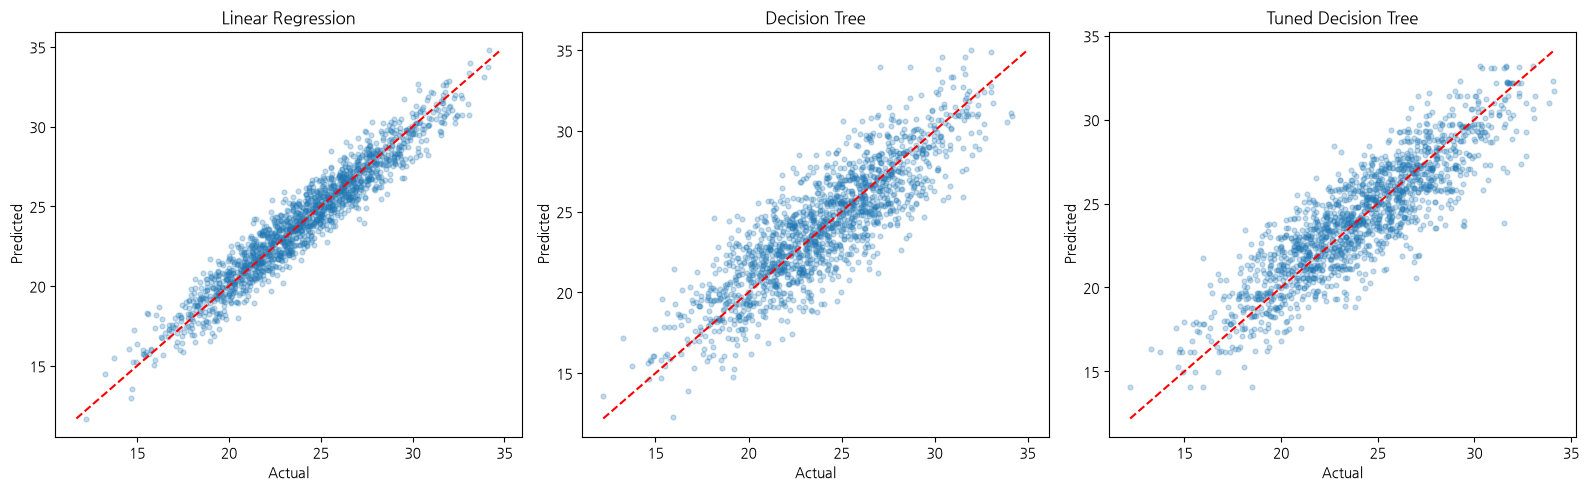

In [98]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (model_name, model) in zip(axes, models.items()):
    prediction = model.predict(X_test)
    min_value = min(y_test.min(), prediction.min())
    max_value = max(y_test.max(), prediction.max())

    ax.scatter(y_test, prediction, alpha=0.25, s=12)
    ax.plot([min_value, max_value], [min_value, max_value], 'r--')
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.set_title(model_name)

plt.tight_layout()
plt.show()

## 15. 최종 모델의 잔차 확인
잔차는 `실제값 - 예측값`입니다. 잔차가 0을 중심으로 특별한 모양 없이 퍼져 있으면 비교적 안정적인 예측으로 볼 수 있습니다.

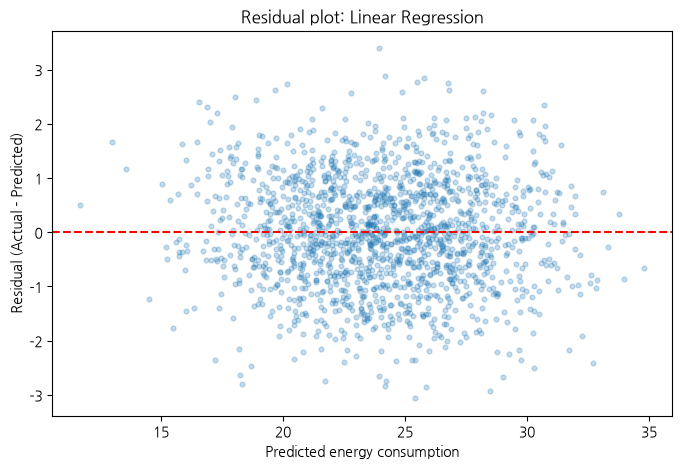

In [99]:
best_prediction = best_model.predict(X_test)
residual = y_test - best_prediction

plt.figure(figsize=(8, 5))
plt.scatter(best_prediction, residual, alpha=0.25, s=12)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted energy consumption')
plt.ylabel('Residual (Actual - Predicted)')
plt.title(f'Residual plot: {best_model_name}')
plt.show()

## 16. 튜닝된 의사결정트리의 변수 중요도
변수 중요도는 트리가 예측 오차를 줄이는 데 각 변수를 얼마나 사용했는지 나타냅니다. 인과관계는 아니며, 비슷한 정보를 가진 변수끼리는 중요도가 나뉠 수 있습니다.

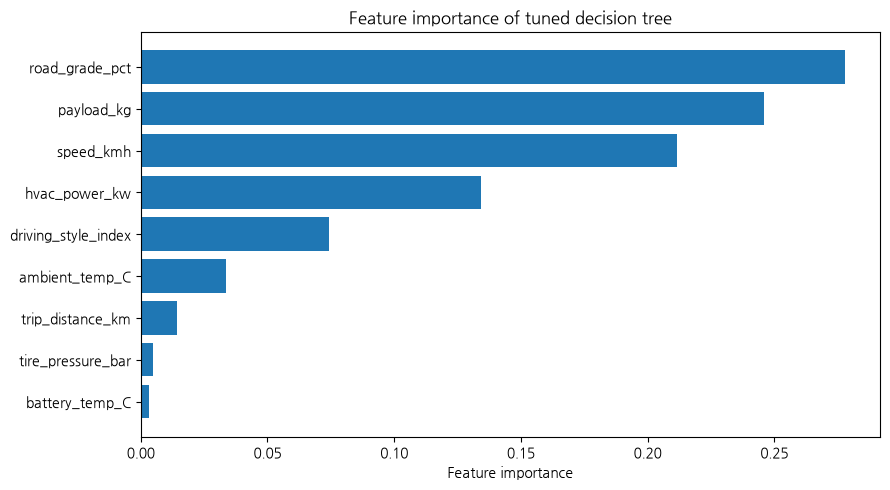

,Importance
road_grade_pct,0.277840
payload_kg,0.245870
speed_kmh,0.211519
hvac_power_kw,0.134418
driving_style_index,0.074108
ambient_temp_C,0.033507
trip_distance_km,0.014490
tire_pressure_bar,0.004868
battery_temp_C,0.003379


In [100]:
tree_importance = (
    pd.Series(tuned_tree.feature_importances_, index=X.columns)
      .sort_values(ascending=True)
)

plt.figure(figsize=(9, 5))
plt.barh(tree_importance.index, tree_importance.values)
plt.xlabel('Feature importance')
plt.title('Feature importance of tuned decision tree')
plt.tight_layout()
plt.show()

tree_importance.sort_values(ascending=False).to_frame('Importance')

## 17. 단일 테스트 행 예측 검증
이 단계는 테스트 데이터 한 행의 실제값과 예측값을 비교하고 소비전력량 계산식을 확인하는 **모델 검증 예시**입니다. 여러 후보 경로를 비교하는 내비게이션 기능 시뮬레이션은 개선 모델을 확정한 뒤 25절에서 별도로 수행합니다.

**구간 소비전력량(kWh) = 예측 에너지 소비율(kWh/100km) × 구간 거리(km) ÷ 100**

도착 SOC 계산에는 현재 SOC와 사용 가능한 배터리 용량이 추가로 필요합니다.

In [101]:
sample_index = X_test.index[0]
sample_X = X_test.loc[[sample_index]]

predicted_rate = best_model.predict(sample_X)[0]
actual_rate = y_test.loc[sample_index]
segment_distance_km = sample_X['trip_distance_km'].iloc[0]
predicted_energy_kwh = predicted_rate * segment_distance_km / 100

usable_battery_kwh = 60
current_soc_pct = 80
arrival_soc_pct = current_soc_pct - (predicted_energy_kwh / usable_battery_kwh * 100)

print(f'실제 에너지 소비율: {actual_rate:.2f} kWh/100km')
print(f'예측 에너지 소비율: {predicted_rate:.2f} kWh/100km')
print(f'구간 거리: {segment_distance_km:.1f} km')
print(f'예상 구간 소비전력량: {predicted_energy_kwh:.2f} kWh')
print(f'도착 예상 SOC: {arrival_soc_pct:.1f}%')

실제 에너지 소비율: 26.01 kWh/100km
예측 에너지 소비율: 26.40 kWh/100km
구간 거리: 176.9 km
예상 구간 소비전력량: 46.71 kWh
도착 예상 SOC: 2.2%


## 18. 1차 모델 비교 결과 정리
지금까지의 모델 비교에서는 다음 내용을 확인합니다.

1. 모델별 학습·테스트 MAE, RMSE, R²
2. 기본 의사결정트리에서 과적합이 발생했는지
3. GridSearchCV가 선택한 최적 파라미터
4. 튜닝 후 테스트 성능이 개선되었는지
5. 주요 변수와 그 의미
6. 예측 정확도뿐 아니라 추론 속도와 해석 가능성을 고려한 최종 모델 선정
7. 현재 데이터로 검증한 범위와 실제 OEM 적용을 위해 추가로 필요한 데이터

## 19. 선형회귀 개선 방향

기존 선형회귀가 가장 좋은 결과를 보였지만, 외기온의 구간별 평균에서는 **너무 추울 때와 너무 더울 때 에너지 소비율이 증가하는 곡선 관계**가 나타났습니다. 기존 모델의 `ambient_temp_C` 한 개 변수는 이 관계를 하나의 직선으로만 표현합니다.

이를 보완하기 위해 다음 두 파생변수를 추가합니다.

- `cold_penalty`: 외기온이 저온 기준보다 낮은 정도
- `hot_penalty`: 외기온이 고온 기준보다 높은 정도

기준 온도는 테스트 결과를 보고 정하지 않고, 학습 데이터를 다시 학습용·검증용으로 나눠 선택합니다.

In [102]:
def add_temperature_features(data, cold_threshold, hot_threshold):
    engineered = data.copy()
    engineered['cold_penalty'] = np.maximum(
        cold_threshold - engineered['ambient_temp_C'],
        0
    )
    engineered['hot_penalty'] = np.maximum(
        engineered['ambient_temp_C'] - hot_threshold,
        0
    )
    return engineered

## 20. 학습 데이터 내부에서 온도 기준 선택
학습 데이터의 20%를 검증용으로 분리하고 저온·고온 기준 후보를 비교합니다. 테스트 데이터는 이 과정에 사용하지 않습니다.

In [103]:
X_inner_train, X_valid, y_inner_train, y_valid = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42
)

cold_candidates = [5, 10, 15, 20]
hot_candidates = [25, 30, 35]
threshold_results = []

for cold_threshold in cold_candidates:
    for hot_threshold in hot_candidates:
        X_inner_engineered = add_temperature_features(
            X_inner_train, cold_threshold, hot_threshold
        )
        X_valid_engineered = add_temperature_features(
            X_valid, cold_threshold, hot_threshold
        )

        candidate_model = LinearRegression()
        candidate_model.fit(X_inner_engineered, y_inner_train)
        valid_prediction = candidate_model.predict(X_valid_engineered)

        threshold_results.append({
            'cold_threshold': cold_threshold,
            'hot_threshold': hot_threshold,
            'Validation MAE': mean_absolute_error(y_valid, valid_prediction),
            'Validation RMSE': np.sqrt(
                mean_squared_error(y_valid, valid_prediction)
            ),
            'Validation R2': r2_score(y_valid, valid_prediction)
        })

threshold_results_df = (
    pd.DataFrame(threshold_results)
      .sort_values('Validation RMSE')
      .reset_index(drop=True)
)

threshold_results_df.round(4)

,cold_threshold,hot_threshold,Validation MAE,Validation RMSE,Validation R2
0,10,30,0.6168,0.7806,0.9547
1,10,25,0.6179,0.7813,0.9546
2,10,35,0.6173,0.7840,0.9543
3,5,25,0.6208,0.7852,0.9542
4,5,30,0.6228,0.7889,0.9538
5,15,30,0.6279,0.7918,0.9534
6,15,35,0.6279,0.7925,0.9533
7,15,25,0.6287,0.7927,0.9533
8,5,35,0.6290,0.7983,0.9526
9,20,25,0.6466,0.8115,0.9511


In [104]:
best_cold_threshold = int(threshold_results_df.loc[0, 'cold_threshold'])
best_hot_threshold = int(threshold_results_df.loc[0, 'hot_threshold'])

print('선택된 저온 기준:', best_cold_threshold, '°C')
print('선택된 고온 기준:', best_hot_threshold, '°C')
print(
    '최저 검증 RMSE:',
    round(threshold_results_df.loc[0, 'Validation RMSE'], 4)
)

선택된 저온 기준: 10 °C
선택된 고온 기준: 30 °C
최저 검증 RMSE: 0.7806


## 21. 개선 선형회귀 학습 및 최종 테스트
선택된 온도 기준으로 전체 학습 데이터를 다시 학습하고, 마지막에 한 번만 테스트 데이터로 성능을 평가합니다.

In [105]:
X_train_improved = add_temperature_features(
    X_train, best_cold_threshold, best_hot_threshold
)
X_test_improved = add_temperature_features(
    X_test, best_cold_threshold, best_hot_threshold
)

improved_linear_model = LinearRegression()
improved_linear_model.fit(X_train_improved, y_train)

improved_train_prediction = improved_linear_model.predict(X_train_improved)
improved_test_prediction = improved_linear_model.predict(X_test_improved)

improved_result = {
    'Model': 'Improved Linear Regression',
    'Train MAE': mean_absolute_error(y_train, improved_train_prediction),
    'Test MAE': mean_absolute_error(y_test, improved_test_prediction),
    'Train RMSE': np.sqrt(
        mean_squared_error(y_train, improved_train_prediction)
    ),
    'Test RMSE': np.sqrt(
        mean_squared_error(y_test, improved_test_prediction)
    ),
    'Train R2': r2_score(y_train, improved_train_prediction),
    'Test R2': r2_score(y_test, improved_test_prediction)
}

pd.DataFrame([improved_result]).round(4)

,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2
0,Improved Linear Regression,0.6469,0.6466,0.8084,0.8112,0.9536,0.9513


## 22. 기존 모델과 개선 모델 비교
모든 모델을 동일한 테스트 데이터에서 비교합니다. 개선 모델의 학습·테스트 성능 차이가 지나치게 커지지 않았는지도 확인합니다.

In [106]:
final_comparison_df = (
    pd.concat(
        [results_df, pd.DataFrame([improved_result])],
        ignore_index=True
    )
    .sort_values('Test RMSE')
    .reset_index(drop=True)
)

rmse_improvement_pct = (
    (linear_result['Test RMSE'] - improved_result['Test RMSE'])
    / linear_result['Test RMSE']
    * 100
)

print(f'기존 선형회귀 대비 RMSE 개선율: {rmse_improvement_pct:.2f}%')
final_comparison_df.round(4)

기존 선형회귀 대비 RMSE 개선율: 19.62%


,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2
0,Improved Linear Regression,0.6469,0.6466,0.8084,0.8112,0.9536,0.9513
1,Linear Regression,0.8052,0.8107,1.0031,1.0093,0.9285,0.9246
2,Tuned Decision Tree,0.9504,1.4330,1.2128,1.8064,0.8956,0.7585
3,Decision Tree,0.0000,1.5588,0.0000,1.9710,1.0000,0.7125


## 23. 개선 전후 예측과 온도 잔차 비교
왼쪽 그래프에서는 점들이 대각선에 가까워졌는지 확인하고, 오른쪽 그래프에서는 온도에 따른 잔차의 곡선 패턴이 줄었는지 확인합니다.

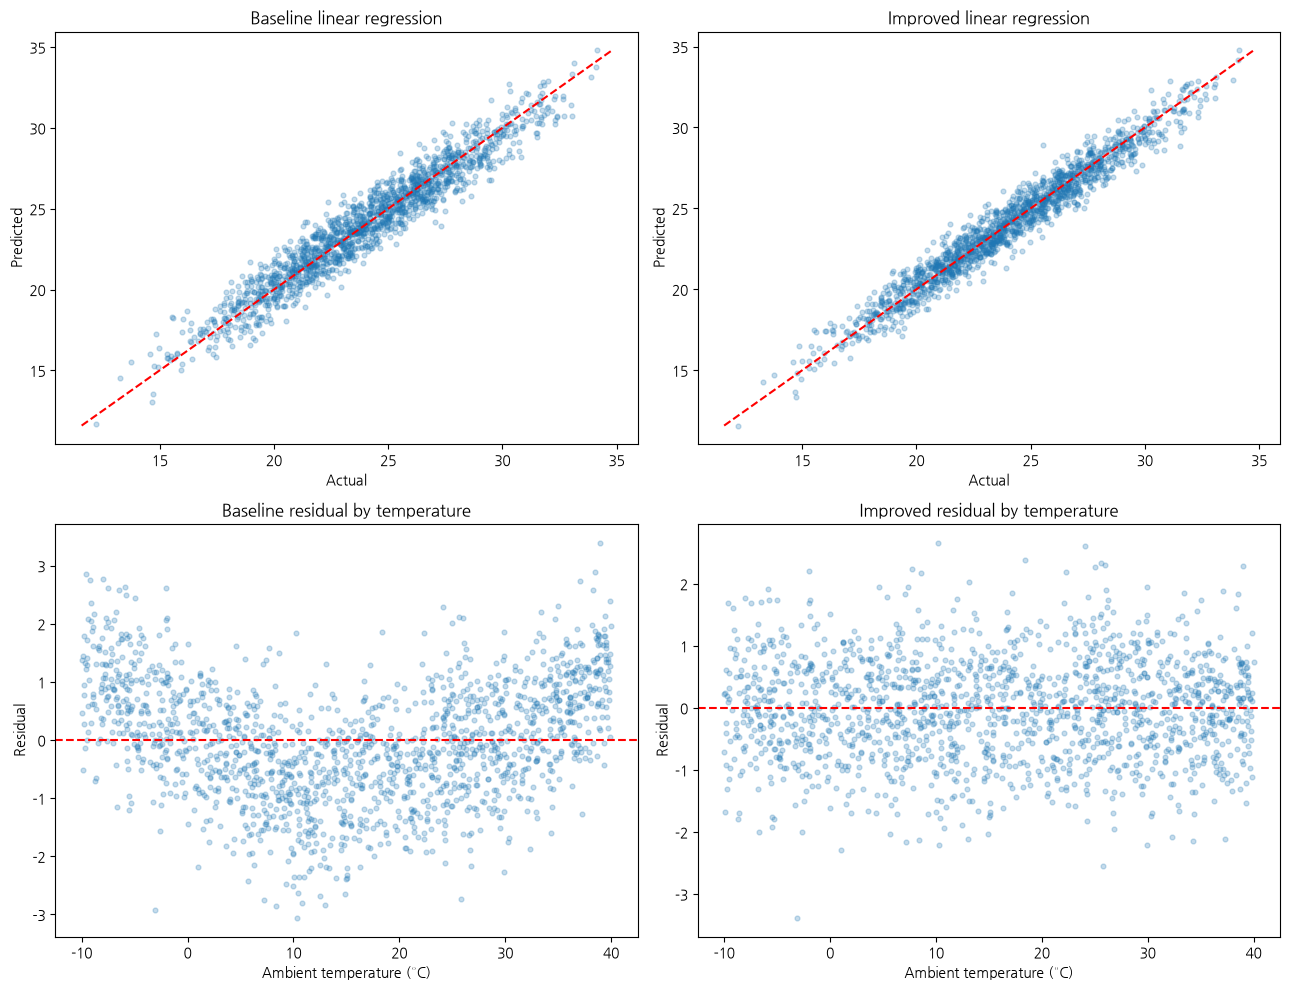

In [107]:
baseline_test_prediction = linear_model.predict(X_test)
baseline_residual = y_test - baseline_test_prediction
improved_residual = y_test - improved_test_prediction

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
min_value = min(y_test.min(), improved_test_prediction.min())
max_value = max(y_test.max(), improved_test_prediction.max())

axes[0, 0].scatter(y_test, baseline_test_prediction, alpha=0.25, s=12)
axes[0, 0].plot([min_value, max_value], [min_value, max_value], 'r--')
axes[0, 0].set_title('Baseline linear regression')
axes[0, 0].set_xlabel('Actual')
axes[0, 0].set_ylabel('Predicted')

axes[0, 1].scatter(y_test, improved_test_prediction, alpha=0.25, s=12)
axes[0, 1].plot([min_value, max_value], [min_value, max_value], 'r--')
axes[0, 1].set_title('Improved linear regression')
axes[0, 1].set_xlabel('Actual')
axes[0, 1].set_ylabel('Predicted')

axes[1, 0].scatter(
    X_test['ambient_temp_C'], baseline_residual, alpha=0.25, s=12
)
axes[1, 0].axhline(0, color='red', linestyle='--')
axes[1, 0].set_title('Baseline residual by temperature')
axes[1, 0].set_xlabel('Ambient temperature (°C)')
axes[1, 0].set_ylabel('Residual')

axes[1, 1].scatter(
    X_test['ambient_temp_C'], improved_residual, alpha=0.25, s=12
)
axes[1, 1].axhline(0, color='red', linestyle='--')
axes[1, 1].set_title('Improved residual by temperature')
axes[1, 1].set_xlabel('Ambient temperature (°C)')
axes[1, 1].set_ylabel('Residual')

plt.tight_layout()
plt.show()

In [108]:
temperature_diagnostics = pd.DataFrame({
    'ambient_temp_C': X_test['ambient_temp_C'],
    'Baseline residual': baseline_residual,
    'Improved residual': improved_residual
})
temperature_diagnostics['temperature_range'] = pd.cut(
    temperature_diagnostics['ambient_temp_C'],
    bins=[-np.inf, 0, 10, 20, 30, np.inf],
    labels=['below 0', '0 to 10', '10 to 20', '20 to 30', 'above 30']
)

temperature_residual_summary = (
    temperature_diagnostics
    .groupby('temperature_range', observed=False)[
        ['Baseline residual', 'Improved residual']
    ]
    .mean()
)

temperature_residual_summary.round(3)

,Baseline residual,Improved residual
temperature_range,,
below 0,0.655,-0.018
0 to 10,-0.390,-0.016
10 to 20,-0.700,-0.044
20 to 30,-0.186,0.054
above 30,0.575,-0.040


## 24. 개선 선형회귀의 표준화 영향도
원래 계수는 변수마다 단위가 달라 크기를 직접 비교하기 어렵습니다. 아래 값은 각 변수가 표준편차 1만큼 변할 때 예측값이 목표변수의 표준편차 단위로 얼마나 변하는지 계산한 보조 지표입니다. 절댓값이 클수록 모델 예측에 미치는 영향이 큽니다. 다만 이는 인과관계를 의미하지 않습니다.

In [109]:
standardized_effect = (
    improved_linear_model.coef_
    * X_train_improved.std(ddof=0).values
    / y_train.std(ddof=0)
)

standardized_effect_df = pd.DataFrame({
    'Feature': X_train_improved.columns,
    'Standardized effect': standardized_effect,
})
standardized_effect_df['Absolute effect'] = (
    standardized_effect_df['Standardized effect'].abs()
)
standardized_effect_df = standardized_effect_df.sort_values(
    'Absolute effect', ascending=False
)

standardized_effect_df.round(4)

,Feature,Standardized effect,Absolute effect
4,road_grade_pct,0.4961,0.4961
1,payload_kg,0.4630,0.4630
0,speed_kmh,0.4390,0.4390
3,hvac_power_kw,0.3448,0.3448
6,driving_style_index,0.2689,0.2689
9,cold_penalty,0.2278,0.2278
8,trip_distance_km,0.1505,0.1505
7,tire_pressure_bar,-0.0903,0.0903
5,battery_temp_C,-0.0682,0.0682
10,hot_penalty,0.0581,0.0581


## 25. 단일 테스트 행 예측 검증
이 단계는 테스트 데이터 한 행의 실제값과 예측값을 비교하고 소비전력량 계산식을 확인하는 **모델 검증 예시**입니다. 개선 모델을 추가로 비교합니다.

**구간 소비전력량(kWh) = 예측 에너지 소비율(kWh/100km) × 구간 거리(km) ÷ 100**

도착 SOC 계산에는 현재 SOC와 사용 가능한 배터리 용량이 추가로 필요합니다.

In [110]:
sample_X_improved = add_temperature_features(
    sample_X, best_cold_threshold, best_hot_threshold
)
improved_predicted_rate = improved_linear_model.predict(
    sample_X_improved
)[0]
improved_energy_kwh = improved_predicted_rate * segment_distance_km / 100
improved_arrival_soc_pct = (
    current_soc_pct
    - improved_energy_kwh / usable_battery_kwh * 100
)

print(f'실제 에너지 소비율: {actual_rate:.2f} kWh/100km')
print(f'기존 모델 예측: {predicted_rate:.2f} kWh/100km')
print(f'개선 모델 예측: {improved_predicted_rate:.2f} kWh/100km')
print(f'개선 모델 예상 소비전력량: {improved_energy_kwh:.2f} kWh')
print(f'개선 모델 도착 예상 SOC: {improved_arrival_soc_pct:.1f}%')

실제 에너지 소비율: 26.01 kWh/100km
기존 모델 예측: 26.40 kWh/100km
개선 모델 예측: 25.95 kWh/100km
개선 모델 예상 소비전력량: 45.91 kWh
개선 모델 도착 예상 SOC: 3.5%


## 26. 후보 경로별 에너지 비교 시뮬레이션
동일한 출발지와 목적지를 연결하는 세 후보 경로를 각각 3개 구간으로 나눕니다. 차량 상태와 외부 환경은 동일하게 고정하고, 경로에 따라 달라지는 구간 거리·예상 속도·도로 경사만 다르게 설정합니다.

세 경로의 주행 속도는 비슷하게 두고, 경로 C만 경사가 완만한 우회 노선으로 설정했습니다. 속도를 낮춰 에너지를 아끼면 소요 시간이 크게 늘어나므로, 절약의 원인을 속도가 아닌 도로 경사에 두기 위함입니다.

각 구간의 에너지 소비율을 예측한 뒤 다음 식으로 구간 소비전력량을 계산하고 경로별로 합산합니다.

**구간 소비전력량(kWh) = 예측 에너지 소비율(kWh/100km) × 구간 거리(km) ÷ 100**

출발 SOC 80%, 사용 가능 배터리 용량 60kWh, 최소 도착 SOC 10%를 가정합니다.

In [111]:
route_segments = pd.DataFrame([
    # route name, segment, distance, expected speed, road grade
    # A: 최단거리이지만 구릉지를 통과해 경사가 크다
    ['Route A (Shortest)', 1, 50, 95, 3.0],
    ['Route A (Shortest)', 2, 50, 90, 4.0],
    ['Route A (Shortest)', 3, 48, 98, 1.5],
    # B: 고속도로. 가장 빠르지만 고속 주행으로 소비가 크다
    ['Route B (Highway)', 1, 56, 115, 1.5],
    ['Route B (Highway)', 2, 58, 120, 2.0],
    ['Route B (Highway)', 3, 52, 110, 1.0],
    # C: 조금 우회하지만 경사가 완만하다. 속도는 A와 비슷하게 유지
    ['Route C (Eco)', 1, 50, 90, 0.5],
    ['Route C (Eco)', 2, 51, 92, 0.0],
    ['Route C (Eco)', 3, 50, 90, 0.0],
], columns=[
    'route_name',
    'segment_id',
    'trip_distance_km',
    'speed_kmh',
    'road_grade_pct'
])

# 동일한 출발 시점에는 경로 간 공통인 차량·환경 조건
route_segments['payload_kg'] = 250
route_segments['ambient_temp_C'] = -5
route_segments['hvac_power_kw'] = 3.0
route_segments['battery_temp_C'] = 25
route_segments['driving_style_index'] = 0.5
route_segments['tire_pressure_bar'] = 2.4

route_model_input = route_segments[X.columns]
route_model_input_improved = add_temperature_features(
    route_model_input, best_cold_threshold, best_hot_threshold
)

route_segments['predicted_rate_kwhper100km'] = (
    improved_linear_model.predict(route_model_input_improved)
)
route_segments['segment_energy_kwh'] = (
    route_segments['predicted_rate_kwhper100km']
    * route_segments['trip_distance_km']
    / 100
)
route_segments['segment_time_min'] = (
    route_segments['trip_distance_km']
    / route_segments['speed_kmh']
    * 60
)

segment_result_columns = [
    'route_name', 'segment_id', 'trip_distance_km',
    'speed_kmh', 'road_grade_pct',
    'predicted_rate_kwhper100km', 'segment_energy_kwh'
]
route_segments[segment_result_columns].round(2)

        route_name  segment_id  trip_distance_km  speed_km  \
0  Route A (Shortest)           1                50        95   
1  Route A (Shortest)           2                50        90   
2  Route A (Shortest)           3                48        98   
3   Route B (Highway)           1                56       115   
4   Route B (Highway)           2                58       120   
5   Route B (Highway)           3                52       110   
6       Route C (Eco)           1                50        90   
7       Route C (Eco)           2                51        92   
8       Route C (Eco)           3                50        90   

   road_grade_pct  predicted_rate_kwhper100km  segment_energy_kwh  
0             3.0                       27.65               13.82  
1             4.0                       27.88               13.94  
2             1.5                       27.04               12.98  
3             1.5                       28.00               15.68  
4           

In [112]:
current_soc_pct = 80
usable_battery_kwh = 60
minimum_arrival_soc_pct = 10

route_summary = (
    route_segments
    .groupby('route_name', as_index=False)
    .agg(
        total_distance_km=('trip_distance_km', 'sum'),
        estimated_time_min=('segment_time_min', 'sum'),
        estimated_energy_kwh=('segment_energy_kwh', 'sum')
    )
)
route_summary['route_rate_kwhper100km'] = (
    route_summary['estimated_energy_kwh']
    / route_summary['total_distance_km']
    * 100
)
route_summary['arrival_soc_pct'] = (
    current_soc_pct
    - route_summary['estimated_energy_kwh']
    / usable_battery_kwh
    * 100
)
route_summary['safe_arrival'] = (
    route_summary['arrival_soc_pct'] >= minimum_arrival_soc_pct
)
route_summary['recommendation'] = ''

feasible_routes = route_summary[route_summary['safe_arrival']]

if feasible_routes.empty:
    recommended_route_name = None
    print('안전 잔량을 충족하는 경로가 없습니다. 충전소 경유가 필요합니다.')
else:
    recommended_index = feasible_routes['estimated_energy_kwh'].idxmin()
    recommended_route_name = route_summary.loc[
        recommended_index, 'route_name'
    ]
    route_summary.loc[
        recommended_index, 'recommendation'
    ] = 'Recommended: minimum energy'
    print('추천 경로:', recommended_route_name)

route_summary.round(2)

추천 경로: Route C (Eco)


           route_name  total_distance_km  estimated_time_min  \
0  Route A (Shortest)                148               94.30   
1   Route B (Highway)                166               86.58   
2       Route C (Eco)                151               99.93   

   estimated_energy_kwh  route_rate_kwhper100km  arrival_soc_pct  \
0                 40.74                   27.53            12.10   
1                 46.50                   28.01             2.51   
2                 39.29                   26.02            14.52   

   safe_arrival               recommendation  
0          True                               
1         False                               
2          True  Recommended: minimum energy  

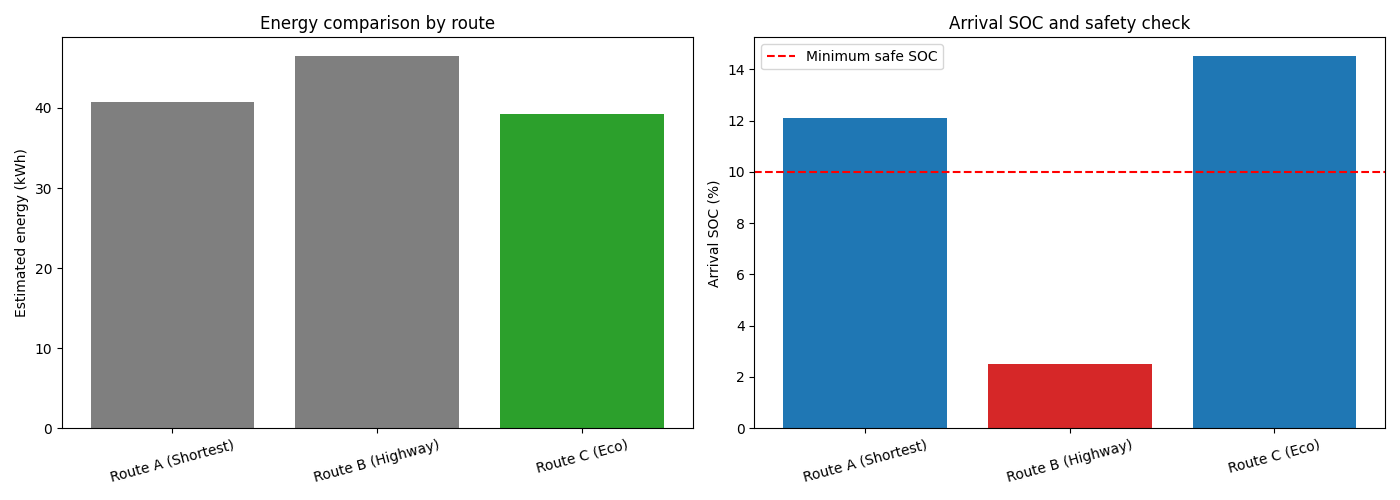

In [113]:
energy_colors = [
    'tab:green' if route == recommended_route_name else 'tab:gray'
    for route in route_summary['route_name']
]
soc_colors = [
    'tab:blue' if safe else 'tab:red'
    for safe in route_summary['safe_arrival']
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(
    route_summary['route_name'],
    route_summary['estimated_energy_kwh'],
    color=energy_colors
)
axes[0].set_ylabel('Estimated energy (kWh)')
axes[0].set_title('Energy comparison by route')
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(
    route_summary['route_name'],
    route_summary['arrival_soc_pct'],
    color=soc_colors
)
axes[1].axhline(
    minimum_arrival_soc_pct,
    color='red',
    linestyle='--',
    label='Minimum safe SOC'
)
axes[1].set_ylabel('Arrival SOC (%)')
axes[1].set_title('Arrival SOC and safety check')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend()

plt.tight_layout()
plt.show()

### 시뮬레이션 해석과 범위
- 경로 A는 가장 짧지만 구릉지를 지나 경사가 크고, 경로 B는 예상 시간이 가장 짧은 고속도로 경로이며, 경로 C는 조금 우회하지만 경사가 완만한 노선입니다. 세 경로의 주행 속도는 90~120km/h로 크게 다르지 않습니다.
- 결과적으로 경로 C는 경로 A보다 3km 길고 5.6분 더 걸리지만, 소비전력량을 1.45kWh 줄이고 도착 SOC를 2.42%p 높입니다. 절약의 원인이 저속 주행이 아니라 완만한 경사이므로 시간 손해가 작습니다.
- 안전 도착이 가능한 경로 중 예상 소비전력량이 가장 작은 경로를 추천합니다. 도착 SOC가 안전 기준보다 낮으면 추천 대상에서 제외합니다.
- 이 결과는 실제 지도 경로 데이터가 아니라 CSV 변수 범위 안에서 만든 **시나리오 기반 기능 시연**입니다.
- 현재 모델은 주행 단위 데이터로 학습됐으므로 각 구간을 하나의 주행처럼 예측한다는 단순화가 들어갑니다.
- 실제 OEM 적용에서는 HD맵 경사, 제한속도, 교통예측으로 경로를 더 작은 구간으로 나누고 구간별 소비전력량을 합산해야 합니다. 또한 차량별 사용 가능 배터리 용량, 회생제동, 충전소 위치와 안전 여유분을 함께 반영해야 합니다.

## 27. 최종 모델 선정 기준

다음 조건을 모두 만족하면 개선 선형회귀를 최종 후보로 선정합니다.

1. 기존 선형회귀보다 테스트 MAE와 RMSE가 감소할 것
2. 테스트 R²가 증가할 것
3. 학습·테스트 성능 차이가 작아 과적합이 심하지 않을 것
4. 온도 구간별 잔차 편향이 감소할 것
5. 단순한 계산 구조와 설명 가능성을 유지할 것

저온·고온 파생변수까지 포함한 선형회귀는 계산량이 작고 각 변수의 영향 방향을 설명할 수 있어 OEM 내비게이션의 임베디드 적용 후보로 적합합니다. 25절에서는 이 예측값을 구간별 에너지 비용으로 변환해 후보 경로의 소비전력량과 도착 SOC를 비교했습니다. 다만 실제 적용 전에는 실차 주행 데이터, 차량별 배터리 특성, 회생제동, 교통상황과 구간별 도로 조건을 이용한 추가 검증이 필요합니다.